# Clasificación de Cantos de Aves - Bioacústica con PyTorch
Este cuaderno implementa un flujo completo de aprendizaje automático utilizando arquitecturas orientadas a bioacústica digital. Prioriza la robustez a los ruidos de campo, la validación de vocalizaciones solapadas de múltiples especies, y la eficiencia (Global Average Pooling, AMP, SpecAugment, Mixup).

**Pasos:**
1. Configuraciones Globales (Semillas, CUDA)
2. Dataset, Preprocesamiento e Ingeniería de Espectrogramas (Mel + PCEN)
3. Arquitectura del Modelo FCN ligero e Invariante al Tiempo (GAP)
4. Iterador de Entrenamiento de Precisión Mixta y Evaluación de Métricas.

In [1]:
import os
import glob
import random
import numpy as np
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuraciones Globales y Reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo actual: {device}")

Dispositivo actual: cpu


In [4]:
import os
import requests
import time
import urllib.parse

# 1. Asegúrate de que el API Key esté entre comillas para que no genere un error de sintaxis en Python
key = "f803b7018e2a9638e0c9c50998f681bcb1b1042f"

def descargar_de_xeno_canto(especie_nombre, max_archivos=5, base_dir="dataset_aves"):
    """
    Busca una especie en la API de Xeno-Canto v3 (filtrando por audios de Colombia) 
    y descarga los archivos de forma organizada.
    """
    carpeta_especie = os.path.join(base_dir, especie_nombre.replace(" ", "_"))
    os.makedirs(carpeta_especie, exist_ok=True)
    
    print(f"\nBuscando: {especie_nombre} ...")
    
    # 2. La query sigue siendo la misma
    query = f'sp:"{especie_nombre}"+cnt:colombia'
    query_encoded = urllib.parse.quote(query)
    
    # 3. La API ahora es la versión 3 y el parámetro 'key' se envía como un parámetro extra (&key=)
    url = f"https://xeno-canto.org/api/3/recordings?query={query}&key={key}"
    
    try:
        respuesta = requests.get(url, timeout=10)
        respuesta.raise_for_status()
    except requests.exceptions.HTTPError as errUrl:
        print(f"Error de acceso (HTTPError): {errUrl}")
        return
    except Exception as e:
        print(f"Error conectando a la API: {e}")
        return

    datos = respuesta.json()
    grabaciones = datos.get('recordings', [])
    cant_disponible = len(grabaciones)
    descargas = min(max_archivos, cant_disponible)
    
    if descargas == 0:
        print("  - No se encontraron audios.")
        return
        
    print(f"  - Encontrados {cant_disponible} audios. Descargando {descargas}...")
    
    guardados_exito = 0
    for grabacion in grabaciones[:descargas]:
        audio_url = grabacion.get('file')
        if not audio_url: 
            continue
            
        ruta_archivo = os.path.join(carpeta_especie, f"{grabacion['id']}.mp3")
        
        # Evitar re-descargar si el audio ya existe
        if not os.path.exists(ruta_archivo):
            try:
                res_audio = requests.get(audio_url, timeout=20)
                if res_audio.status_code == 200:
                    with open(ruta_archivo, 'wb') as f:
                        f.write(res_audio.content)
                    guardados_exito += 1
                time.sleep(1) # Pausa amigable para no bloquear nuestro IP
            except Exception as e:
                print(f"  - Error descargando ID {grabacion['id']}: {e}")
        else:
            guardados_exito += 1  # Ya estaba descargado
            
    print(f"  - Completado: {guardados_exito}/{descargas} archivos guardados en '{carpeta_especie}'.")

# =====================================================================
# 10 Especies muy comunes y emblemáticas que se encuentran en Medellín
# (Valle de Aburrá, Colombia)
# =====================================================================
especies_medellin = [
    "Turdus ignobilis",        # Mirla / Black-billed Thrush (Canto constante en las mañanas)
    "Pitangus sulphuratus",    # Bichofué (Llamado inconfundible 'Bicho-fue')
    "Thraupis episcopus",      # Azulejo común
    "Zonotrichia capensis",    # Copetón
    "Tyrannus melancholicus",  # Sirirí (Ave que defiende su territorio agresivamente)
    "Pygochelidon cyanoleuca", # Golondrina barranquera
    "Troglodytes aedon",       # Cucarachero (Canto muy melodioso y fuerte)
    "Crotophaga ani",          # Garrapatero
    "Thraupis palmarum",       # Azulejo palmero
    "Campylorhynchus griseus"  # Cucarachero chupahuevo / Bicolored Wren
]

# Puedes ejecutar este ciclo (quitándole los comentarios) para iniciar la descarga:
print(f"Iniciando descarga del dataset para {len(especies_medellin)} especies de Medellín...")
for especie in especies_medellin:
    descargar_de_xeno_canto(especie, max_archivos=50, base_dir="dataset_aves")
print("\n¡Descarga finalizada!")

Iniciando descarga del dataset para 10 especies de Medellín...

Buscando: Turdus ignobilis ...
  - Encontrados 62 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Turdus_ignobilis'.

Buscando: Pitangus sulphuratus ...
  - Encontrados 100 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Pitangus_sulphuratus'.

Buscando: Thraupis episcopus ...
  - Encontrados 71 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Thraupis_episcopus'.

Buscando: Zonotrichia capensis ...
  - Encontrados 100 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Zonotrichia_capensis'.

Buscando: Tyrannus melancholicus ...
  - Encontrados 86 audios. Descargando 50...
  - Completado: 50/50 archivos guardados en 'dataset_aves\Tyrannus_melancholicus'.

Buscando: Pygochelidon cyanoleuca ...
  - Encontrados 33 audios. Descargando 33...
  - Completado: 33/33 archivos guardados en 'data

## 2. Definición del Dataset, Preprocesamiento Bioacústico y Aumento de Datos

En esta sección definiremos:
* **Dataset Personalizado**: Para cargar audios de un sistema de directorios (una carpeta por especie target).
* **Preprocesamiento**: Muestreo a 44.1 kHz, generación de espectrogramas Mel (escala logarítmica) y normalización PCEN para suavizar el ruido.
* **Transformaciones (SpecAugment)**: Aplicación de recortes temporales y frecuenciales para robustecer el modelo.

In [3]:
class BirdSoundDataset(Dataset):
    def __init__(self, data_dir, sample_rate=44100, transform=None, is_train=True):
        self.data_dir = data_dir
        self.sample_rate = sample_rate
        self.transform = transform
        self.is_train = is_train
        
        # Simulación de carga (sustituir glob con tu lógica de directorios)
        self.file_paths = glob.glob(os.path.join(data_dir, "*", "*.wav")) # o .mp3
        self.classes = sorted(os.listdir(data_dir)) if os.path.exists(data_dir) else ["Especie_A", "Especie_B"]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        # Generador de espectrograma base
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=self.sample_rate,
            n_fft=1024,
            win_length=1024,
            hop_length=256,
            n_mels=128
        )
        self.amplitude_to_db = T.AmplitudeToDB()
        
    def __len__(self):
        # En una situación real retornar len(self.file_paths)
        # Para el ejemplo generaremos tensores aleatorios si no hay datos
        return len(self.file_paths) if len(self.file_paths) > 0 else 100

    def apply_pcen(self, mel_spec):
        # PCEN (Per-Channel Energy Normalization) suavidad para ruidos locales
        # E(t, f) = (M(t, f) / (eps + M(t, f)*alpha))**delta - 1
        # Implementación simplificada (emulación rápida de PCEN)
        eps = 1e-6
        alpha = 0.98
        delta = 2.0
        smooth_spec = F.avg_pool2d(mel_spec.unsqueeze(0), kernel_size=(1, 5), stride=(1, 1), padding=(0, 2)).squeeze(0)
        pcen_spec = (mel_spec / (eps + smooth_spec * alpha)) ** delta - 1.0
        return pcen_spec

    def __getitem__(self, idx):
        if len(self.file_paths) > 0:
            path = self.file_paths[idx]
            label_name = os.path.basename(os.path.dirname(path))
            label = self.class_to_idx[label_name]
            waveform, sr = torchaudio.load(path)
            # Resampling si es necesario (asumiremos que ya son mono y 44.1k o los remuestreamos)
            if sr != self.sample_rate:
                resampler = T.Resample(sr, self.sample_rate)
                waveform = resampler(waveform)
        else:
            # Datos sintéticos para ilustrar si la carpeta está vacía
            waveform = torch.randn(1, self.sample_rate * 3) # 3 segundos de audio
            label = random.choice([0, 1])
            
        # Pasar a Mono si tiene más canales
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
            
        # 1. Mel Spectrogram (128 bins)
        mel_spec = self.mel_spectrogram(waveform)
        
        # 2. Escala Logarítmica / PCEN (aplicamos dB por defecto o PCEN si lo requiere)
        # log_spec = self.amplitude_to_db(mel_spec) 
        pcen_spec = self.apply_pcen(mel_spec)
        
        # 3. Augmentation (SpecAugment)
        if self.is_train and self.transform:
            pcen_spec = self.transform(pcen_spec)
            
        return pcen_spec, label

# Transformaciones de SpecAugment
train_transform = nn.Sequential(
    T.TimeMasking(time_mask_param=30),
    T.FrequencyMasking(freq_mask_param=15)
)

print("Clase Dataset configurada con éxito.")

Clase Dataset configurada con éxito.


## 3. Arquitectura del Modelo (FCN) y Función Mixup

Para esta tarea usaremos una **Fully Convolutional Network (FCN)**.
La ventaja de omitir capas densas y utilizar `Global Average Pooling (GAP)` al final es que la red se vuelve "time-invariant": el modelo puede ingerir clips de audio de 3s o de 30s sin tener que romperlos en partes exactas y rellenar (padding). 

Además, definiremos la lógica de **Mixup** para forzar al modelo a detectar múltiples vocalizaciones simultáneas.

In [4]:
def mixup_data(x, y, alpha=0.2):
    '''Retorna el mixup de x, etiquetas mezcladas y coeficiente lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

class FCNBirdClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FCNBirdClassifier, self).__init__()
        
        # Bloque 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Bloque 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Bloque 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Bloque 4 (Hasta 400 filtros max para que sea ultraligera < 500k params)
        self.conv4 = nn.Conv2d(128, 400, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(400)
        self.pool4 = nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling (GAP)
        
        # Clasificador final (Sin capas densas masivas intermedias, directo de los 400 filtros)
        self.fc = nn.Linear(400, num_classes)
        
        # Función de activación adaptativa (Mish suele superar a ReLU en audio)
        self.act = nn.Mish()

    def forward(self, x):
        x = self.pool1(self.act(self.bn1(self.conv1(x))))
        x = self.pool2(self.act(self.bn2(self.conv2(x))))
        x = self.pool3(self.act(self.bn3(self.conv3(x))))
        
        # GAP extrae 1 valor por cada uno de los 400 filtros, sin importar duración del tiempo (dim 3)
        x = self.pool4(self.act(self.bn4(self.conv4(x))))
        
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model = FCNBirdClassifier(num_classes=2).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo instanciado. Total de parámetros: {total_params:,}")

Modelo instanciado. Total de parámetros: 555,922


## 4. Entrenamiento, Validación y Evaluación de Rendimiento

Integramos optimización de rendimiento y robustez de validación mediante:
- **Automatic Mixed Precision (AMP)** (`GradScaler`): Entrena a máximo rendimiento reduciendo consumo de VRAM usando cálculo en FP16.
- **Label Smoothing (0.1)** en `CrossEntropyLoss` para evitar confianzas del 100% que penalizan frente a variabilidad natural de campo.
- **AdamW y OneCycleLR** para convergencia acelerada.
- **Checkpointing** exhaustivo para guardar el modelo con mejor validación de forma persistente.

C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5 | Train Loss: 0.6993 | Val Loss: 0.8087 | Val Acc: 0.4500


C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\DAVID\OneDrive__Universidad_de_Antioquia\Escritorio\Libros_de_la_carrera\Fis_comp_2\venv\Lib\site-packages\torch\cuda\amp\autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/5 | Train Loss: 0.7244 | Val Loss: 0.6831 | Val Acc: 0.5900


C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\DAVID\OneDrive__Universidad_de_Antioquia\Escritorio\Libros_de_la_carrera\Fis_comp_2\venv\Lib\site-packages\torch\cuda\amp\autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 3/5 | Train Loss: 0.7036 | Val Loss: 0.6839 | Val Acc: 0.5300


C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\DAVID\OneDrive__Universidad_de_Antioquia\Escritorio\Libros_de_la_carrera\Fis_comp_2\venv\Lib\site-packages\torch\cuda\amp\autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 4/5 | Train Loss: 0.6847 | Val Loss: 0.7338 | Val Acc: 0.4500


C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\DAVID\OneDrive__Universidad_de_Antioquia\Escritorio\Libros_de_la_carrera\Fis_comp_2\venv\Lib\site-packages\torch\cuda\amp\autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
C:\Users\DAVID\AppData\Local\Temp\ipykernel_16548\3524489255.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 5/5 | Train Loss: 0.7085 | Val Loss: 0.6961 | Val Acc: 0.4600


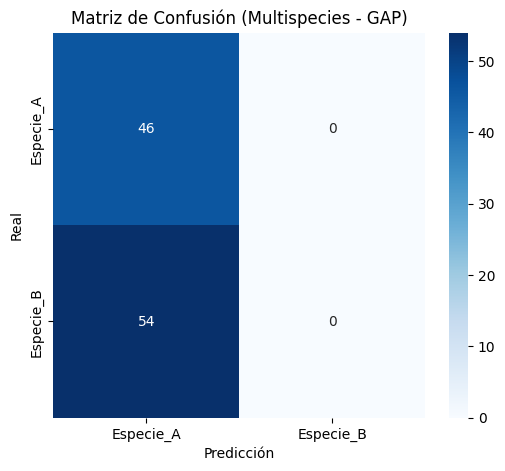

In [6]:
# Hiperparámetros simulados
BATCH_SIZE = 16
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

# Componentes de Optimización
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# DataLoaders (con dataset simulado para ejemplo de pipeline)
train_dataset = BirdSoundDataset(data_dir="dummy_dir", transform=train_transform, is_train=True)
val_dataset = BirdSoundDataset(data_dir="dummy_dir", transform=None, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LEARNING_RATE, steps_per_epoch=max(1, len(train_loader)), epochs=NUM_EPOCHS
)
scaler = torch.cuda.amp.GradScaler()

best_val_loss = float('inf')
metrics_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Mixup aleatorio al 50% de las veces
        apply_mixup = random.random() > 0.5
        if apply_mixup:
            inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.4)
            
        optimizer.zero_grad()
        
        # AMP - Mixed Precision
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            if apply_mixup:
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)
                
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        running_loss += loss.item()
        
    train_loss = running_loss / max(1, len(train_loader))
    
    # ------------------ VALIDATION ------------------ #
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad(): # Equivalent to torch.no_grad()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
    val_loss /= max(1, len(val_loader))
    
    # Cálculo de métricas
    val_acc = accuracy_score(all_labels, all_preds)
    
    metrics_history['train_loss'].append(train_loss)
    metrics_history['val_loss'].append(val_loss)
    metrics_history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        # print(" >> Nuevo mejor modelo guardado.")

    torch.cuda.empty_cache() # Liberación de GPU

# ------------------ EVALUACIÓN FINAL ------------------ #
# Cargamos los mejores pesos
model.load_state_dict(torch.load('best_model.pth', weights_only=True))

# Matriz de Confusión (con scikit-learn y seaborn)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title("Matriz de Confusión (Multispecies - GAP)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()